In [1]:
# notebooks/model_experimentation.ipynb

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

In [2]:
# Configure Premium Seaborn Aesthetics
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='darkgrid', palette='mako')
plt.rcParams['figure.figsize'] = (10, 8)


In [3]:
# Load the preprocessed train and test data
train_data = np.load('../data/models/preprocessed_data.npy')
test_data = np.load('../data/models/test_data.npy')

In [4]:
# Convert the NumPy arrays to pandas DataFrames
train_df = pd.DataFrame(train_data, columns=['feature_' + str(i) for i in range(train_data.shape[1] - 1)] + ['target'])
test_df = pd.DataFrame(test_data, columns=['feature_' + str(i) for i in range(test_data.shape[1] - 1)] + ['target'])

In [5]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
import numpy as np

def plot_evaluation(y_true, y_pred, y_prob, model_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. Confusion Matrix (Safe normalization mapping)
    cm = confusion_matrix(y_true, y_pred)
    row_sums = cm.sum(axis=1)[:, np.newaxis]
    cm_norm = np.divide(cm.astype('float'), row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)
    
    sns.heatmap(cm_norm, annot=True, cmap='Blues', fmt='.2f', ax=ax1,
                xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'])
    ax1.set_title(f'{model_name} Confusion Matrix (Normalized)', pad=15)
    ax1.set_ylabel('True Label')
    ax1.set_xlabel('Predicted Label')
    
    # 2. ROC-AUC curve
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)
        ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        ax2.set_xlim([0.0, 1.0])
        ax2.set_ylim([0.0, 1.05])
        ax2.set_xlabel('False Positive Rate')
        ax2.set_ylabel('True Positive Rate')
        ax2.set_title(f'{model_name} Receiver Operating Characteristic', pad=15)
        ax2.legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()

In [6]:
# Split the train and test data into features and target
X_train = train_df.drop('target', axis=1)
y_train = train_df['target']
X_test = test_df.drop('target', axis=1)
y_test = test_df['target']

Random Forest Classifier Metrics:
Accuracy: 0.9550
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000


/Users/mudit/tf_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


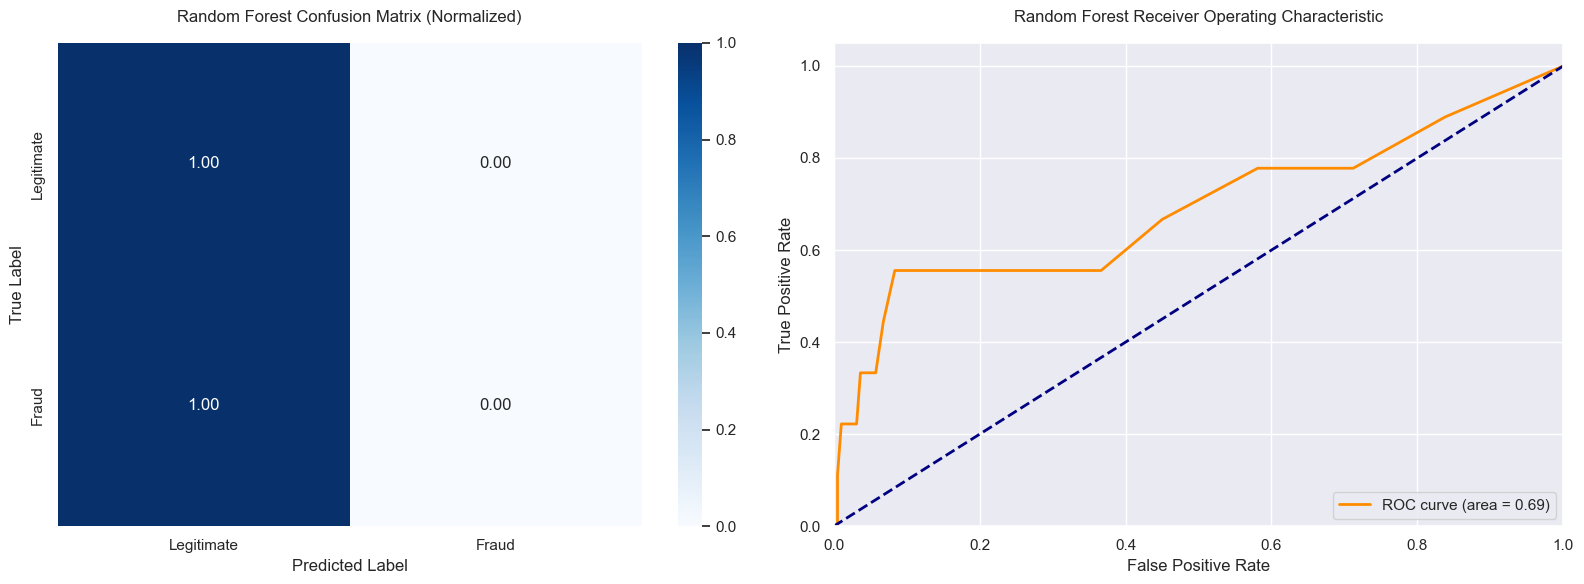

In [7]:
# Random Forest Classifier with Visualizations
rf_model = RandomForestClassifier(random_state=42)

y_train_encoded = np.where(y_train > 0.5, 1, 0)
y_test_encoded = np.where(y_test > 0.5, 1, 0)

rf_model.fit(X_train, y_train_encoded)
rf_predictions = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Classifier Metrics:")
print(f"Accuracy: {accuracy_score(y_test_encoded, rf_predictions):.4f}")
print(f"Precision: {precision_score(y_test_encoded, rf_predictions):.4f}")
print(f"Recall: {recall_score(y_test_encoded, rf_predictions):.4f}")
print(f"F1 Score: {f1_score(y_test_encoded, rf_predictions):.4f}")

plot_evaluation(y_test_encoded, rf_predictions, rf_probs, 'Random Forest')

XGBoost Classifier Metrics:
Accuracy: 0.9550
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000


/Users/mudit/tf_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


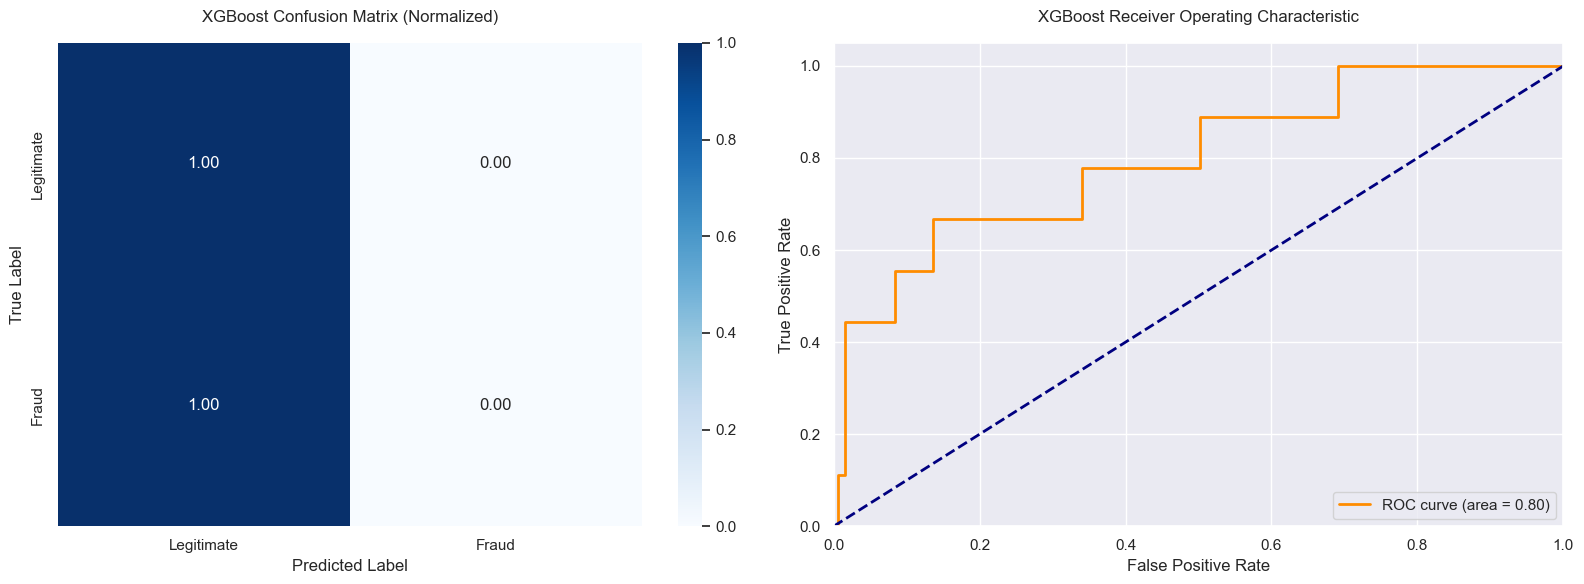

In [8]:
# XGBoost Classifier with Visualizations
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')

xgb_model.fit(X_train, y_train_encoded)
xgb_predictions = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Classifier Metrics:")
print(f"Accuracy: {accuracy_score(y_test_encoded, xgb_predictions):.4f}")
print(f"Precision: {precision_score(y_test_encoded, xgb_predictions):.4f}")
print(f"Recall: {recall_score(y_test_encoded, xgb_predictions):.4f}")
print(f"F1 Score: {f1_score(y_test_encoded, xgb_predictions):.4f}")

plot_evaluation(y_test_encoded, xgb_predictions, xgb_probs, 'XGBoost')

Random Forest Classifier Metrics:
Accuracy: 0.9550
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000


/Users/mudit/tf_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


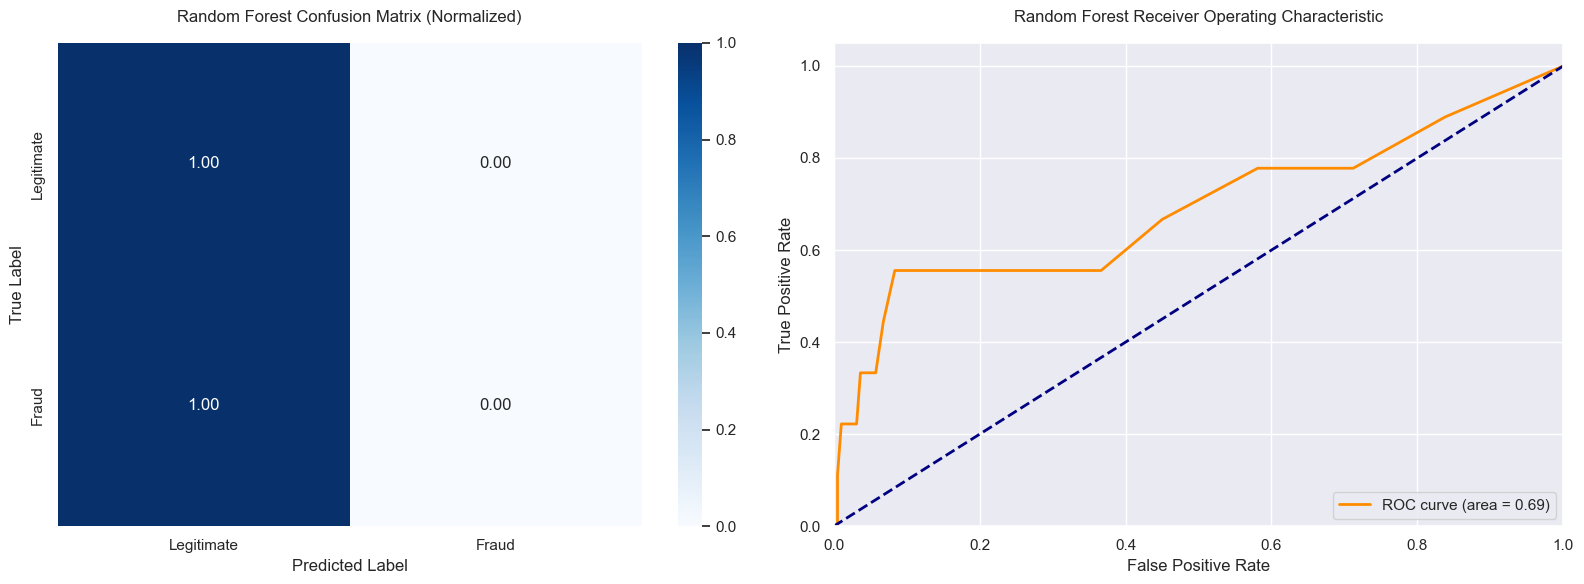

In [9]:
# Random Forest Classifier with Visualizations
rf_model = RandomForestClassifier(random_state=42)

y_train_encoded = np.where(y_train > 0.5, 1, 0)
y_test_encoded = np.where(y_test > 0.5, 1, 0)

rf_model.fit(X_train, y_train_encoded)
rf_predictions = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Classifier Metrics:")
print(f"Accuracy: {accuracy_score(y_test_encoded, rf_predictions):.4f}")
print(f"Precision: {precision_score(y_test_encoded, rf_predictions):.4f}")
print(f"Recall: {recall_score(y_test_encoded, rf_predictions):.4f}")
print(f"F1 Score: {f1_score(y_test_encoded, rf_predictions):.4f}")

plot_evaluation(y_test_encoded, rf_predictions, rf_probs, 'Random Forest')

XGBoost Classifier Metrics:
Accuracy: 0.9550
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000


/Users/mudit/tf_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


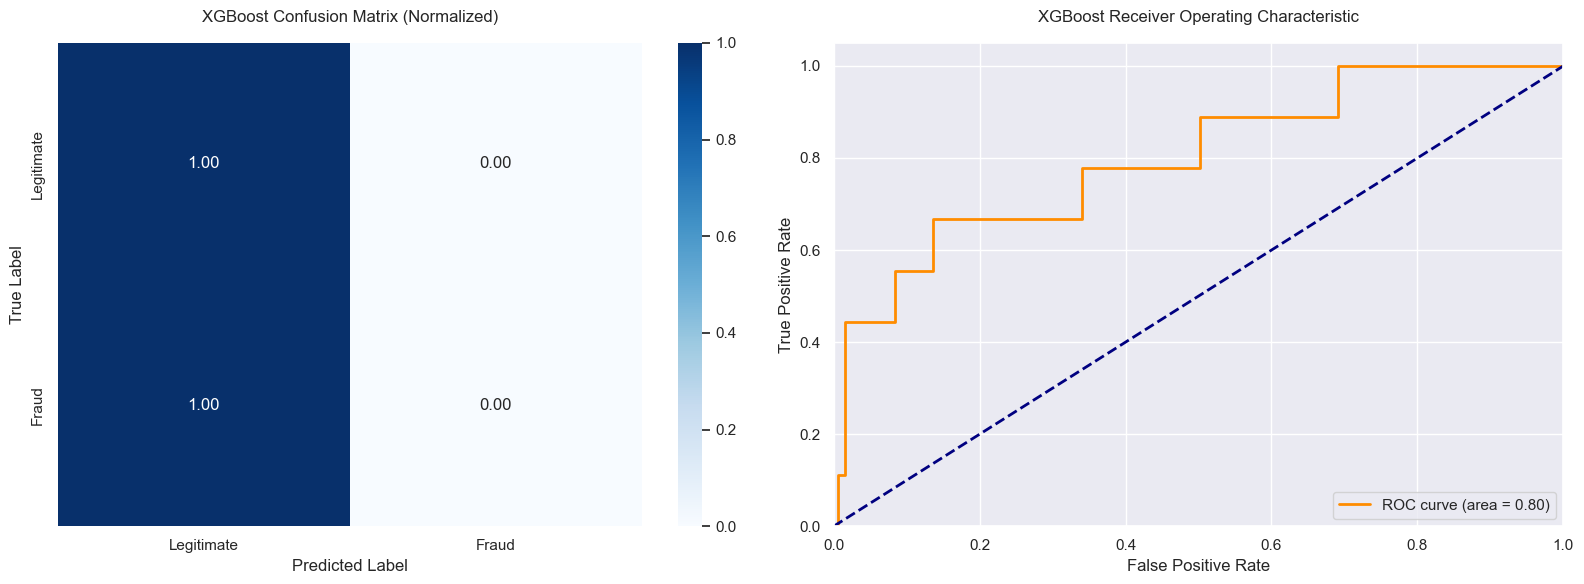

In [10]:
# XGBoost Classifier with Visualizations
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')

xgb_model.fit(X_train, y_train_encoded)
xgb_predictions = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Classifier Metrics:")
print(f"Accuracy: {accuracy_score(y_test_encoded, xgb_predictions):.4f}")
print(f"Precision: {precision_score(y_test_encoded, xgb_predictions):.4f}")
print(f"Recall: {recall_score(y_test_encoded, xgb_predictions):.4f}")
print(f"F1 Score: {f1_score(y_test_encoded, xgb_predictions):.4f}")

plot_evaluation(y_test_encoded, xgb_predictions, xgb_probs, 'XGBoost')